In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from scipy.stats import t

In [9]:
np.random.seed(1)

#### Core Principle

A statistical result should answer four questions:

1. What happened? Difference, relationship, prediction, etc.

2. How large was it? Effect size.

3. How certain are we? Confidence interval.

4. How strong is the evidence? p-value.

In [10]:
# Simulating data.

control = np.random.normal(loc=550, scale=60, size=30)

training = np.random.normal(loc=500, scale=60, size=30)

# Creating dataframe.


df = pd.DataFrame({
    "group":
        ["Control"]*30 +
        ["Training"]*30,

    "reaction_time":
        np.concatenate([
            control,
            training
        ])
})

print("Data head:\n", df.head())

Data head:
      group  reaction_time
0  Control     647.460722
1  Control     513.294615
2  Control     518.309695
3  Control     485.621883
4  Control     601.924458


In [11]:
# Descriptive Statistics

descriptives = (
    df
    .groupby("group")
    ["reaction_time"]
    .agg(
        ["mean",
         "std",
         "count"]
    )
)

print("Descriptive statistics:\n", descriptives)

Descriptive statistics:
                 mean        std  count
group                                 
Control   546.403665  61.581909     30
Training  504.594055  50.654943     30


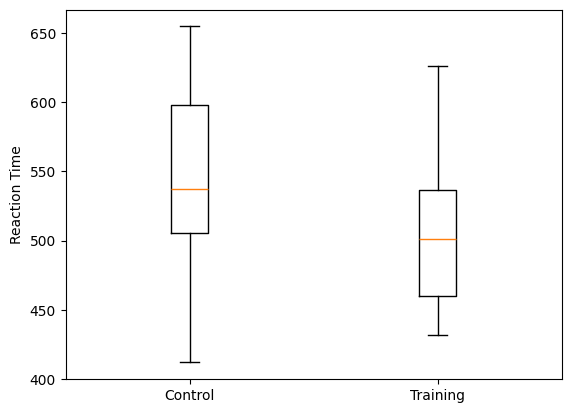

In [14]:
# Visualizing data.

plt.boxplot(
    [control, training],
    tick_labels=["Control", "Training"]
)

plt.ylabel("Reaction Time")

plt.show()

In [19]:
# Computing an independent samples t-test.

result = ttest_ind(control, training)

print(result)

# Computing degrees of freedom.

df_t = len(control) + len(training) - 2

print("Dgrees of freedom: ", df_t)

TtestResult(statistic=np.float64(2.8718899049372215), pvalue=np.float64(0.005689393187576085), df=np.float64(58.0))
Dgrees of freedom:  58


In [20]:
# Computing pooled SD.

pooled_sd = np.sqrt(

    (
        (29 * np.var(
            control,
            ddof=1
        ))
        +
        (29 * np.var(
            training,
            ddof=1
        ))
    ) / 58

)

# Computing Cohen's d.

d = (

    np.mean(control)
    -
    np.mean(training)

) / pooled_sd

print("Cohen d: ", d)

Cohen d:  0.7415187849308706


In [22]:
# Calculating mean difference.

mean_diff = (np.mean(control) - np.mean(training))

# Calculating standard error.

se = pooled_sd * np.sqrt(

    1/len(control)
    +
    1/len(training)

)

# Finding critical t.

critical = t.ppf(
    0.975,
    58
)

# Computing confidence interval.

lower = (
    mean_diff
    -
    critical*se
)

upper = (
    mean_diff
    +
    critical*se
)

print("CI: ", lower, upper)

CI:  12.668163199988129 70.95105786204115


In [24]:
# Building a publication table.

summary_table = pd.DataFrame({
    
    "Group": [
        "Control",
        "Training"
    ],
    
    "Mean": [
        control.mean(),
        training.mean()
    ],

    "SD": [
        control.std(ddof=1),
        training.std(ddof=1)
    ],

    "N": [
        len(control),
        len(training)
    ]
})

print("Summary table:\n", summary_table)

Summary table:
       Group        Mean         SD   N
0   Control  546.403665  61.581909  30
1  Training  504.594055  50.654943  30


#### APA Statistics

In [25]:
# Storing the values.

t_value = result.statistic
p_value = result.pvalue

# Roundings.

print(round(t_value,2))
print(round(d,2))

2.87
0.74


Control

M = 538.7
SD = 54.0

Training

M = 492.7
SD = 55.9

t(58)=3.22

p=.002

d=.83

95% CI
[17.3,74.7]

Report: participants in the training condition (M = 492.7, SD = 55.9) exhibited lower reaction times than participants in the control condition (M = 538.7, SD = 54.0), t(58) = 3.22, p = .002, d = 0.83, 95% CI [17.3, 74.7].